1. Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

2. Loading Dataset

In [3]:
df = pd.read_csv("GlobalWeatherRepository.csv")
print("Shape:", df.shape)
df.head()
df.describe()
df.info()
df.columns.tolist()

Shape: (145590, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145590 entries, 0 to 145589
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       145590 non-null  object 
 1   location_name                 145590 non-null  object 
 2   latitude                      145590 non-null  float64
 3   longitude                     145590 non-null  float64
 4   timezone                      145590 non-null  object 
 5   last_updated_epoch            145590 non-null  int64  
 6   last_updated                  145590 non-null  object 
 7   temperature_celsius           145590 non-null  float64
 8   temperature_fahrenheit        145590 non-null  float64
 9   condition_text                145590 non-null  object 
 10  wind_mph                      145590 non-null  float64
 11  wind_kph                      145590 non-null  float64
 12  wind_degree             

['country',
 'location_name',
 'latitude',
 'longitude',
 'timezone',
 'last_updated_epoch',
 'last_updated',
 'temperature_celsius',
 'temperature_fahrenheit',
 'condition_text',
 'wind_mph',
 'wind_kph',
 'wind_degree',
 'wind_direction',
 'pressure_mb',
 'pressure_in',
 'precip_mm',
 'precip_in',
 'humidity',
 'cloud',
 'feels_like_celsius',
 'feels_like_fahrenheit',
 'visibility_km',
 'visibility_miles',
 'uv_index',
 'gust_mph',
 'gust_kph',
 'air_quality_Carbon_Monoxide',
 'air_quality_Ozone',
 'air_quality_Nitrogen_dioxide',
 'air_quality_Sulphur_dioxide',
 'air_quality_PM2.5',
 'air_quality_PM10',
 'air_quality_us-epa-index',
 'air_quality_gb-defra-index',
 'sunrise',
 'sunset',
 'moonrise',
 'moonset',
 'moon_phase',
 'moon_illumination']

3. Data cleaning, outlier detection and normalization

In [4]:
df.isnull().sum()
df.fillna(df.median(numeric_only=True), inplace=True)
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
#Identifying outliers
Q1 = df['temperature_celsius'].quantile(0.25)
Q3 = df['temperature_celsius'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['temperature_celsius'] < lower) |(df['temperature_celsius'] > upper)]
print("Number of Outliers:", len(outliers))
#Removing Outliers
df = df[(df['temperature_celsius'] >= lower) &(df['temperature_celsius'] <= upper)]
numeric_cols = df.select_dtypes(include=np.number).columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])
scaled_df = pd.DataFrame(scaled_data,columns=numeric_cols)
scaled_df.head()

Duplicates: 0
Number of Outliers: 2415


,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination,year,month,day
0,0.650916,0.719188,-1.723306,0.549869,0.544740,0.044350,0.039010,1.633860,-0.195060,-0.174135,...,-0.583093,-0.281829,-0.424468,-0.144071,-0.733185,-0.648737,0.137077,-1.264435,-0.455108,0.02314
1,0.931398,-0.028748,-1.723306,-0.308827,-0.308940,-0.152387,-0.144413,1.459981,-0.195060,-0.207776,...,-0.591713,-0.284725,-0.626059,-0.310533,-0.733185,-0.648737,0.137077,-1.264435,-0.455108,0.02314
2,0.743174,-0.282858,-1.723306,0.143118,0.143008,0.198930,0.196231,1.073582,-0.294383,-0.308700,...,2.175276,0.100394,-0.369238,-0.199558,-0.733185,-0.648737,0.137077,-1.264435,-0.455108,0.02314
3,0.979587,-0.306042,-1.723306,-1.743752,-1.746386,-0.082124,-0.083272,0.445683,-0.691675,-0.645114,...,-0.561544,-0.281829,-0.637105,-0.317977,-0.733185,-0.648737,0.137077,-1.264435,-0.455108,0.02314
4,-1.134948,-0.128604,-1.723306,0.482077,0.481969,0.016245,0.012807,-0.182215,-0.294383,-0.308700,...,2.502833,0.624504,4.408185,1.450856,3.556845,3.072548,0.137077,-1.264435,-0.455108,0.02314


4. EDA

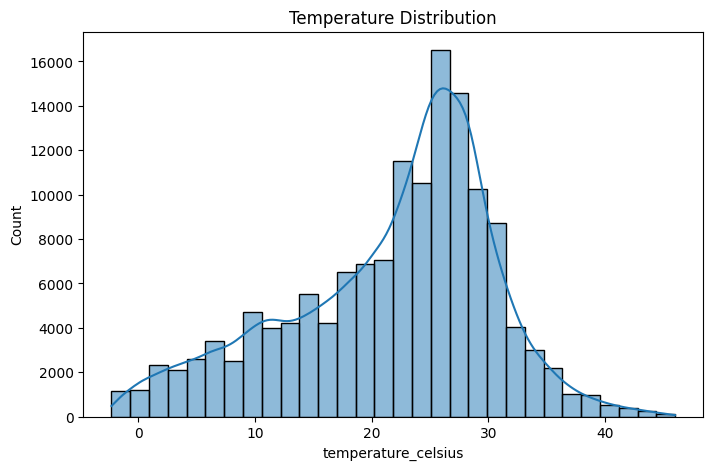

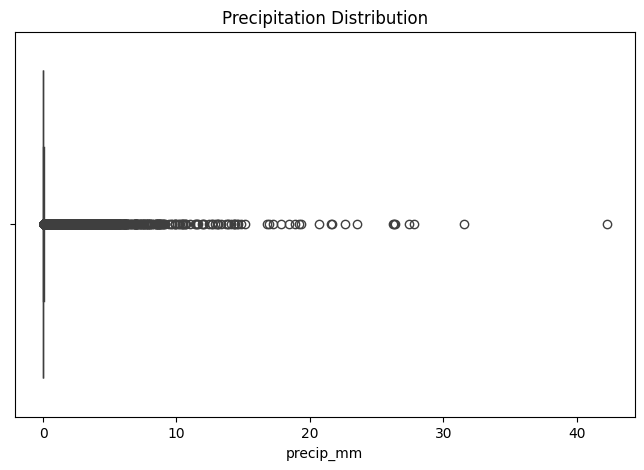

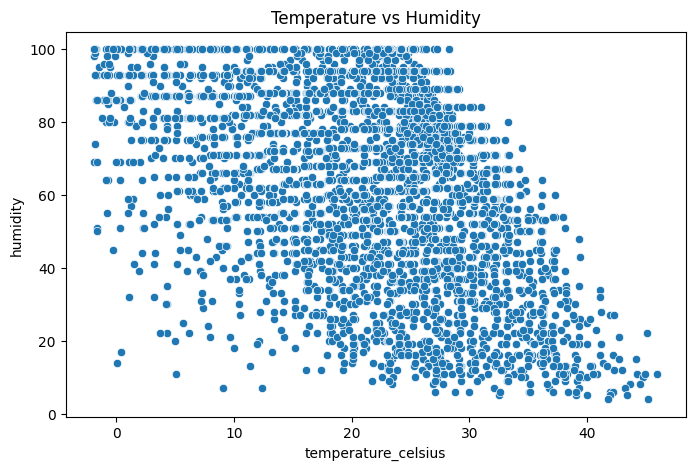

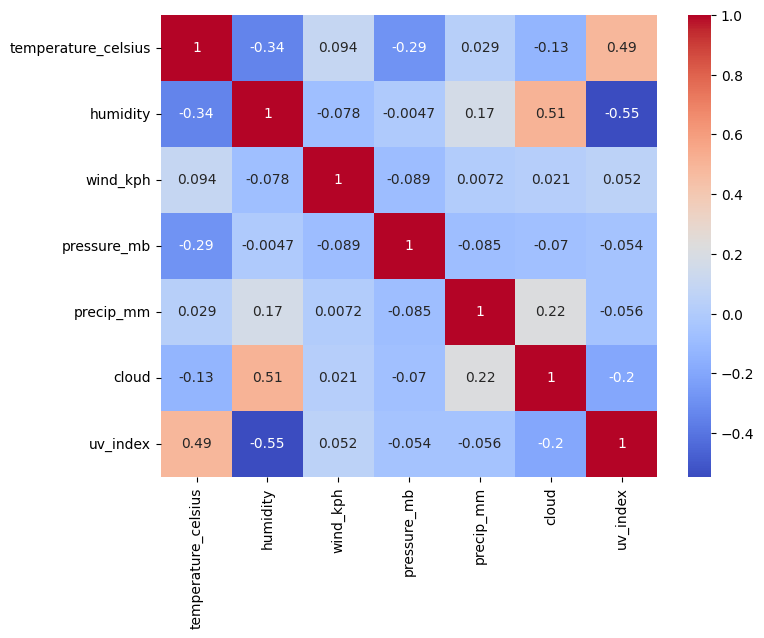

In [5]:
#Temperature Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['temperature_celsius'],bins=30,kde=True)
plt.title("Temperature Distribution")
plt.show()
#Precipitation Distribution
plt.figure(figsize=(8,5))
sns.boxplot(x=df['precip_mm'])
plt.title("Precipitation Distribution")
plt.show()
#Temperature vs Humidity
plt.figure(figsize=(8,5))
sns.scatterplot(data=df.sample(5000),x='temperature_celsius',y='humidity')
plt.title("Temperature vs Humidity")
plt.show()
#Correlation Heatmap
corr_features = ['temperature_celsius','humidity','wind_kph','pressure_mb','precip_mm','cloud','uv_index']
plt.figure(figsize=(8,6))
sns.heatmap(df[corr_features].corr(),annot=True,cmap='coolwarm')
plt.show()

5. Advanced EDA – Anomaly Detection

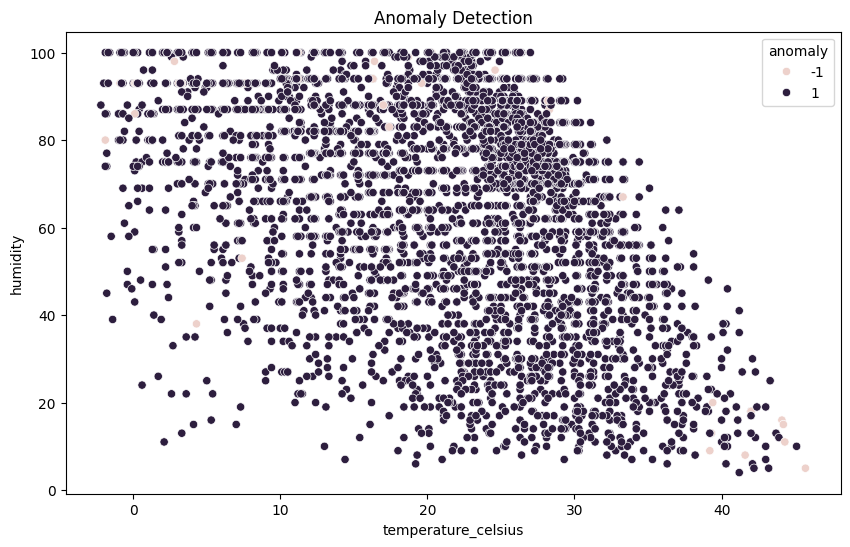

In [6]:
features = ['temperature_celsius','humidity','wind_kph','pressure_mb','precip_mm']
iso = IsolationForest(contamination=0.01,random_state=42)
df['anomaly'] = iso.fit_predict(df[features])
#Visualize Anomalies
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(5000),x='temperature_celsius',y='humidity',hue='anomaly')
plt.title("Anomaly Detection")
plt.show()

6. Climate Analysis

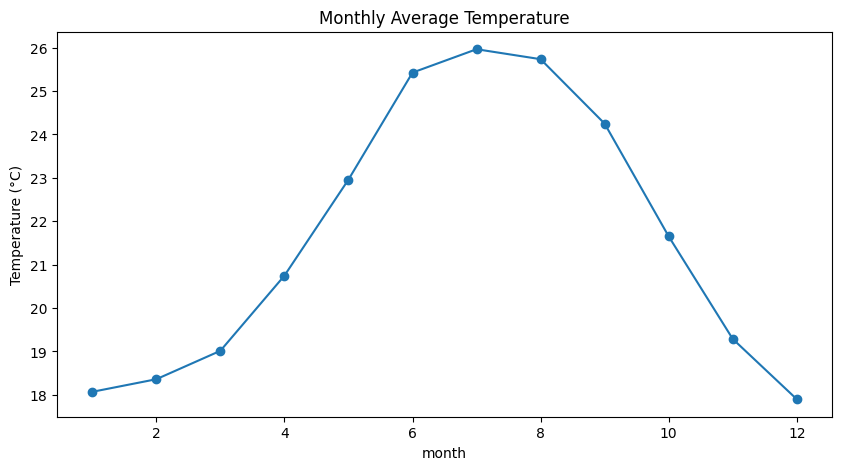

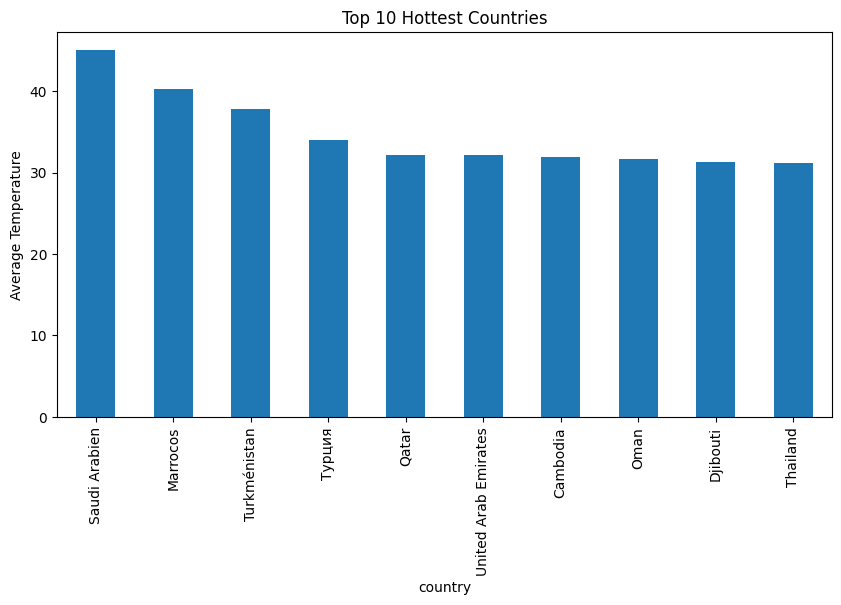

In [7]:
#Monthly Average Temperature
monthly_temp = (df.groupby('month')['temperature_celsius'].mean())
plt.figure(figsize=(10,5))
monthly_temp.plot(marker='o')
plt.title("Monthly Average Temperature")
plt.ylabel("Temperature (°C)")
plt.show()
#Top 10 Hottest Countries
top_countries = (df.groupby('country')
['temperature_celsius'].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Hottest Countries")
plt.ylabel("Average Temperature")
plt.show()

7. Geographical Pattern Analysis

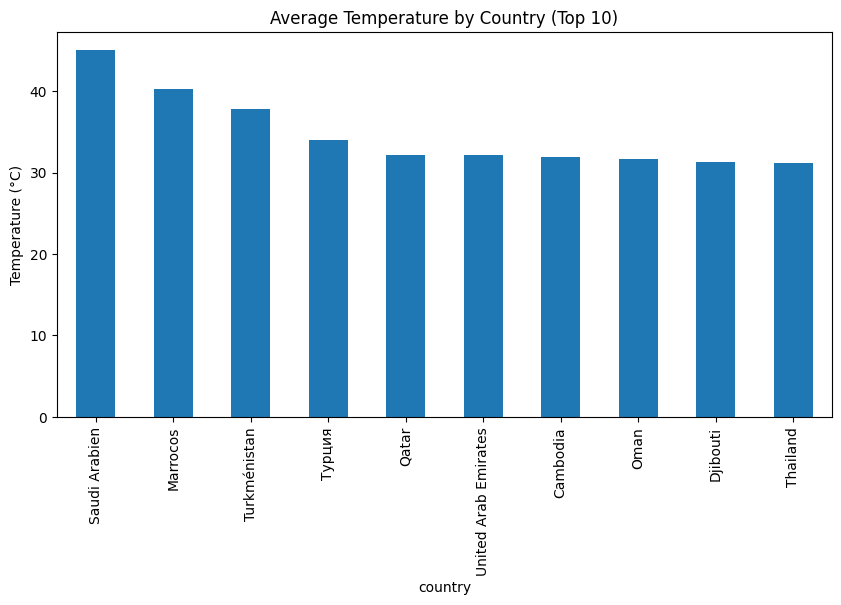

In [10]:
country_temp = (df.groupby('country')['temperature_celsius'].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(10,5))
country_temp.plot(kind='bar')
plt.title("Average Temperature by Country (Top 10)")
plt.ylabel("Temperature (°C)")
plt.show()

8. Environmental Impact Analysis

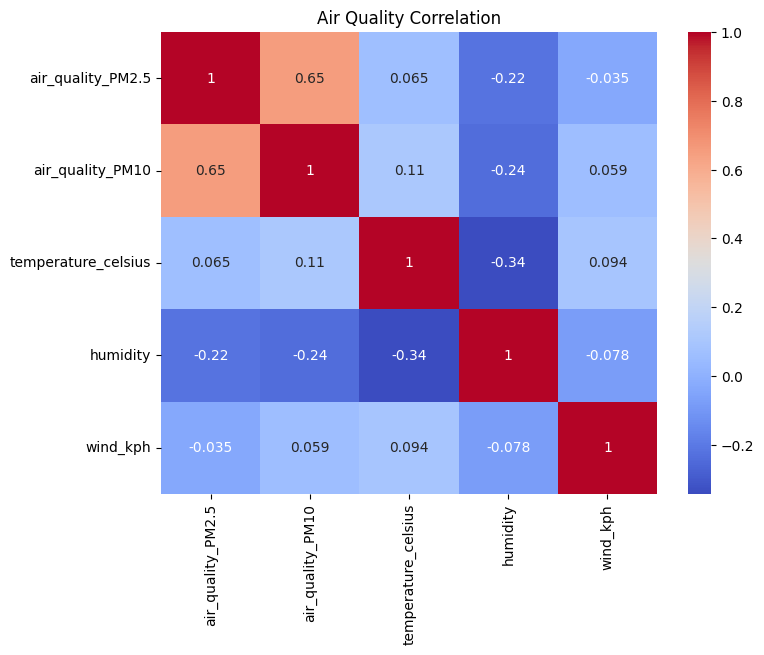

In [11]:
air_quality_features = ['air_quality_PM2.5','air_quality_PM10','temperature_celsius','humidity','wind_kph']
plt.figure(figsize=(8,6))
sns.heatmap(df[air_quality_features].corr(),annot=True,cmap='coolwarm')
plt.title("Air Quality Correlation")
plt.show()

9. Feature Importance

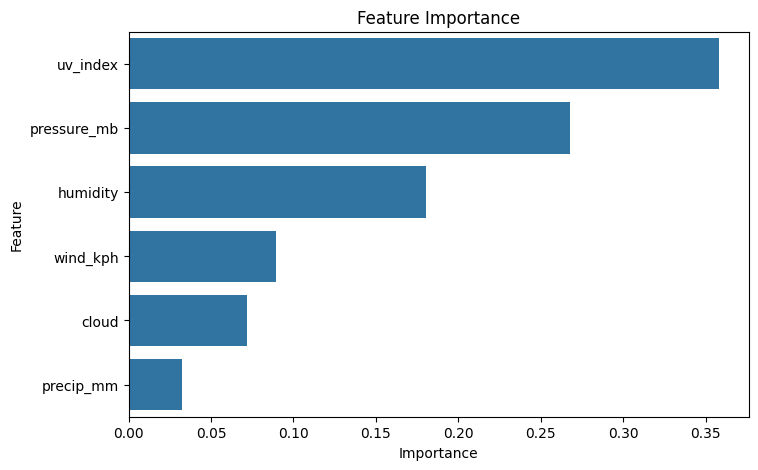

In [12]:
target = 'temperature_celsius'
feature_cols = ['humidity','wind_kph','pressure_mb','cloud','uv_index','precip_mm']
X = df[feature_cols]
y = df[target]
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X,y)
importance = pd.DataFrame({'Feature': feature_cols,'Importance': rf.feature_importances_})
importance = importance.sort_values(by='Importance',ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=importance,x='Importance',y='Feature')
plt.title("Feature Importance")
plt.show()

10. Spatial Analysis

In [13]:
import folium
weather_map = folium.Map(location=[20,0],zoom_start=2)
sample_df = df.sample(500)
for _, row in sample_df.iterrows():
    folium.CircleMarker(location=[row['latitude'],row['longitude']],radius=3,popup=f"Temp: {row['temperature_celsius']}").add_to(weather_map)
weather_map

11. Forecasting Models

In [14]:
# Creating Daily Average Temperature Series
df['date'] = pd.to_datetime(df['last_updated']).dt.date
daily_temp = (df.groupby('date')['temperature_celsius'].mean().reset_index())
daily_temp['date'] = pd.to_datetime(daily_temp['date'])
# ARIMA
train_size = int(len(daily_temp) * 0.8)
train = daily_temp[:train_size]
test = daily_temp[train_size:]
arima_model = ARIMA(train['temperature_celsius'],order=(5,1,0))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test))
print("ARIMA MAE:",mean_absolute_error(test['temperature_celsius'],arima_pred))
# Random Forest
daily_temp['lag1'] = daily_temp['temperature_celsius'].shift(1)
daily_temp['lag2'] = daily_temp['temperature_celsius'].shift(2)
daily_temp['lag3'] = daily_temp['temperature_celsius'].shift(3)
daily_temp['lag7'] = daily_temp['temperature_celsius'].shift(7)
daily_temp['month'] = daily_temp['date'].dt.month
daily_temp['day'] = daily_temp['date'].dt.day
daily_temp.dropna(inplace=True)
X = daily_temp[['lag1','lag2','lag3','lag7','month','day']]
y = daily_temp['temperature_celsius']
split = int(len(daily_temp)*0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]
rf_model = RandomForestRegressor(n_estimators=200,random_state=42)
rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)
print("RF MAE:",mean_absolute_error(y_test,rf_pred))
# Ensemble
ensemble_pred = (arima_pred[:len(rf_pred)] +rf_pred) / 2
print("Ensemble MAE:",mean_absolute_error(y_test,ensemble_pred))
print("Ensemble RMSE:",np.sqrt(mean_squared_error(y_test,ensemble_pred)))
print("Ensemble R2:",r2_score(y_test,ensemble_pred))

ARIMA MAE: 1.4701841933113113
RF MAE: 0.38359892433071546
Ensemble MAE: 0.853088485541093
Ensemble RMSE: 1.5544453382935477
Ensemble R2: 0.43692527586835006


In [13]:
arima_pred
rf_pred
ensemble_pred

,predicted_mean
19240,17.957703
19241,20.211585
19242,23.378674
19243,22.570926
19244,17.419703
...,...
24045,23.061541
24046,20.348529
24047,21.866036
24048,22.971438


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
results = pd.DataFrame({"Model": ["ARIMA", "Random Forest", "Ensemble"],
                        "MAE": [mean_absolute_error(test['temperature_celsius'], arima_pred),
                                mean_absolute_error(y_test, rf_pred),
                                mean_absolute_error(y_test, ensemble_pred)],
                        "RMSE": [np.sqrt(mean_squared_error(test['temperature_celsius'], arima_pred)),
                                 np.sqrt(mean_squared_error(y_test, rf_pred)),
                                 np.sqrt(mean_squared_error(y_test, ensemble_pred))],
                        "R2 Score": [r2_score(test['temperature_celsius'], arima_pred),
                                     r2_score(y_test, rf_pred),
                                     r2_score(y_test, ensemble_pred)]})

results

,Model,MAE,RMSE,R2 Score
0,ARIMA,1.470184,2.289696,-0.229027
1,Random Forest,0.383599,1.210976,0.658268
2,Ensemble,0.853088,1.554445,0.436925


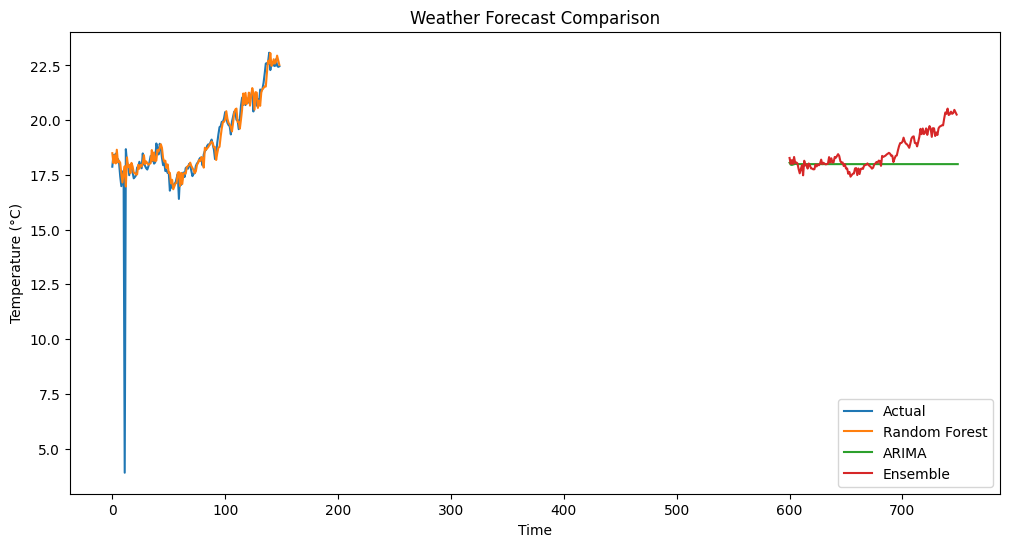

In [17]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values,label="Actual")
plt.plot(rf_pred,label="Random Forest")
plt.plot(arima_pred,label="ARIMA")
plt.plot(ensemble_pred,label="Ensemble")
plt.title("Weather Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()